In [14]:
import xarray as xr
import matplotlib.pyplot as plt
from aqua.core.graphics import plot_single_map_diff, ConfigStyle
from aqua.core.logger import log_configure

In [5]:
# Import results from the biases_production.ipynb notebook
folder = "/work/users/mnurisso/DestinE_paper/Figure4/netcdf"

icon_file_mask = f"{folder}/*ICON*.nc"
ifs_nemo_file_mask = f"{folder}/*IFS-NEMO*.nc"
ifs_fesom_file_mask = f"{folder}/*IFS-FESOM*.nc"
era5_file_mask = f"{folder}/*ERA5*.nc"

icon_climatology = xr.open_mfdataset(icon_file_mask)
ifs_nemo_climatology = xr.open_mfdataset(ifs_nemo_file_mask)
ifs_fesom_climatology = xr.open_mfdataset(ifs_fesom_file_mask)
era5_climatology = xr.open_mfdataset(era5_file_mask)

In [43]:
var = 'u'
loglevel = 'INFO'
titles = ['ICON', 'IFS-NEMO', 'IFS-FESOM']
suptitle = 'Global bias of Zonal Wind Speed at 850 hPa (m/s) with respect to ERA5 climatology (1990-2015)'

In [44]:
def plot_biases(models: list, ref: xr.DataArray, var: str, folder: str,
                suptitle: str, titles: list,
                vmin_fill: float, vmax_fill: float,
                vmin_contour: float, vmax_contour: float,
                cmap: str, loglevel: str = 'INFO'):
    """
    Plot biases of different models with respect to a reference dataset.

    Args:
        models (list): List of model datasets.
        ref (xr.DataArray): Reference dataset.
        var (str): Variable to plot.
        folder (str): Folder to save the plots.
        vmin_fill (float): Minimum value for fill color scale.
        vmax_fill (float): Maximum value for fill color scale.
        vmin_contour (float): Minimum value for contour color scale.
        vmax_contour (float): Maximum value for contour color scale.
        cmap (str): Colormap to use.
        loglevel (str): Logging level.
    """
    # Set logger
    logger = log_configure(loglevel, 'plot_biases')

    # Configure AQUA plot style
    ConfigStyle(loglevel=loglevel)

    # Create figure
    nrows = len(models)
    ncols = 1
    figsize = (8, 4 * nrows)
    fig = plt.figure(figsize=figsize)

    for i, model in enumerate(models, 1):
        data = model[var]

        logger.debug(f"Plotting {data}")

        fig, ax = plot_single_map_diff(
            data=data,
            data_ref=ref[var],
            fig=fig,
            ax_pos=(nrows, ncols, i),
            cmap=cmap, title=titles[i - 1],
            vmin_fill=vmin_fill, vmax_fill=vmax_fill,
            vmin_contour=vmin_contour, vmax_contour=vmax_contour,
            return_fig=True, cbar=False, sym=False,
            loglevel=loglevel
        )

    fig.suptitle(suptitle, fontsize=16)

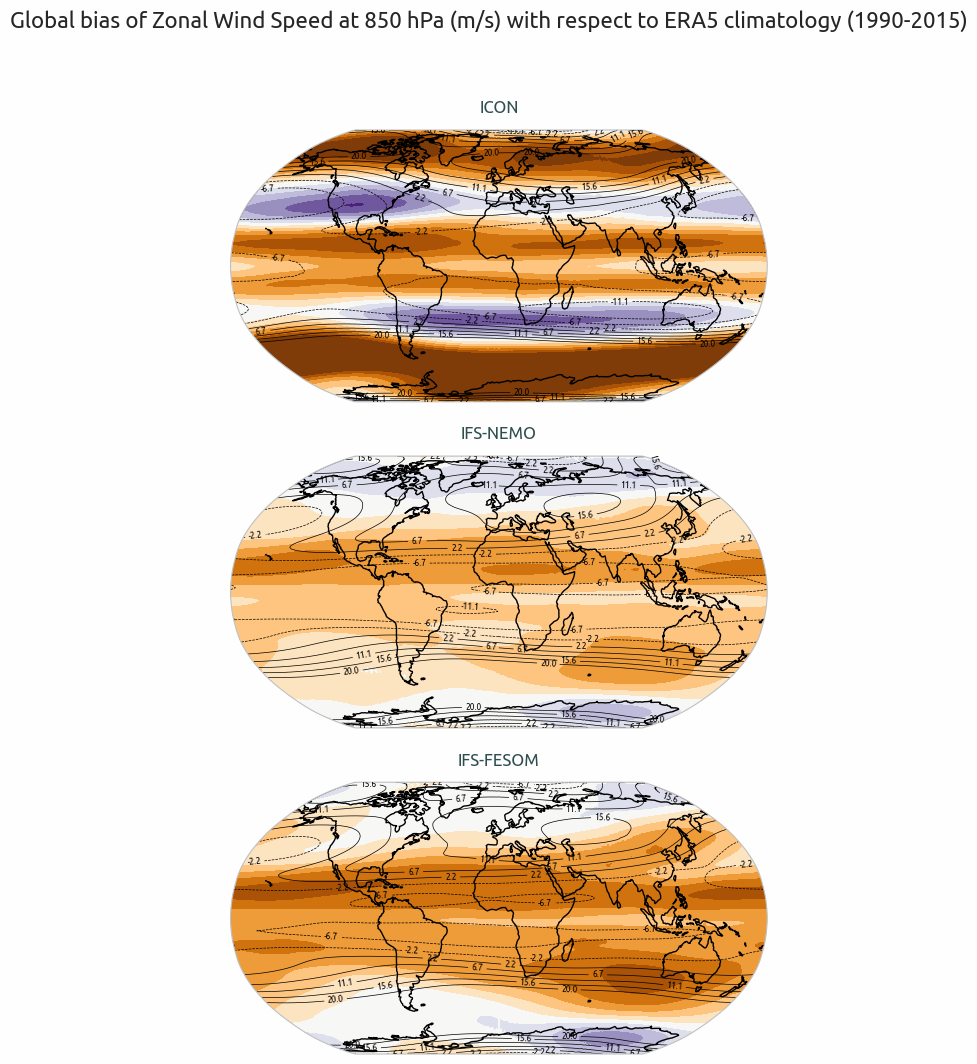

In [46]:
plot_biases(
    models=[icon_climatology, ifs_nemo_climatology, ifs_fesom_climatology],
    ref=era5_climatology,
    var=var,
    folder=folder,
    vmin_fill=-10.0,
    vmax_fill=10.0,
    vmin_contour=-20.0,
    vmax_contour=20.0,
    cmap='PuOr_r',
    titles=titles,
    suptitle=suptitle,
    loglevel=loglevel
)

In [47]:
plot_single_map_diff?

Signature:
plot_single_map_diff(
    data: xarray.core.dataarray.DataArray,
    data_ref: xarray.core.dataarray.DataArray,
    proj: cartopy.crs.Projection = <Projected CRS: +proj=robin +a=6378137.0 +lon_0=0 +no_defs +type=c ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Robinson
Datum: unknown
- Ellipsoid: unknown
- Prime Meridian: Greenwich
,
    extent: Optional[list] = None,
    vmin_fill: Optional[float] = None,
    vmax_fill: Optional[float] = None,
    vmin_contour: Optional[float] = None,
    vmax_contour: Optional[float] = None,
    norm=None,
    sym_contour: bool = False,
    sym: bool = True,
    add_contour: bool = True,
    add_land=False,
    cyclic_lon: bool = True,
    return_fig: bool = False,
    fig: Optional[matplotlib.figure.Figure] = None,
    ax: Optional[matplotlib.axes._axes.Axes] = None,
    title: Optional[str] = None,
    title_size: O